### **שימו לב - ברגע שאתם מעלים את המחברת לגיטהאב שלכם תמחקו את ה key!**



In [ ]:
pip install paho-mqtt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 1.1 MB/s eta 0:00:00


/tmp/ipykernel_7887/2232668216.py:22: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


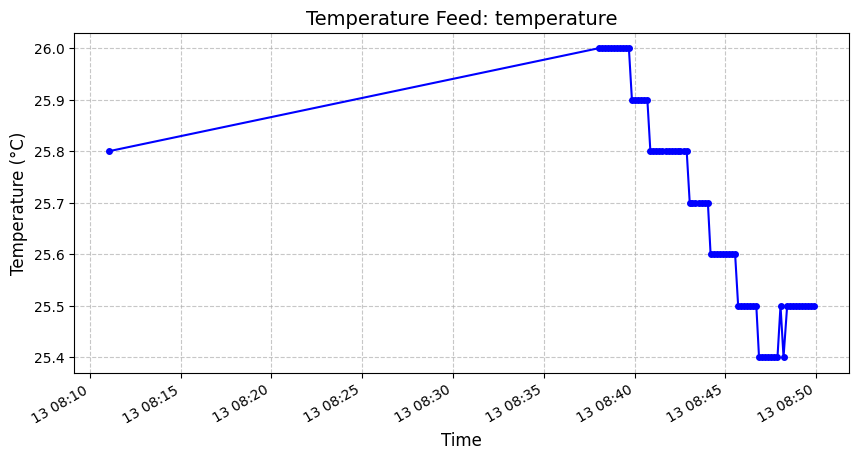

In [ ]:
import paho.mqtt.client as mqtt
import json

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        soil= data.get("soil", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")
        # MQTT setup
broker = "io.adafruit.com"
username = "braude1"   #insert Adafruit user name
aio_key = "removed to download push in github" #insert key from Adafruit
topic = f"{username}/feeds/json"
client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

#print(f"Subscribed to MQTT topic: {topic}")
#client.loop_forever()


import requests
import matplotlib.pyplot as plt
from datetime import datetime

# Configuration
USERNAME = "braude1"
AIO_KEY = "removed to download push in github"
FEED = "temperature"
url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

# Fetch data
response = requests.get(url, headers=headers)
data = response.json()

# Lists to store parsed data
values = []
times = []

# Process the top 100 items
for item in data[:100]:
    # Convert value to float for plotting
    values.append(float(item['value']))

    # Parse the timestamp string into a datetime object
    # Adafruit uses ISO format (e.g., 2023-10-27T10:00:00Z)
    clean_time = item['created_at'].replace('Z', '')
    dt_object = datetime.fromisoformat(clean_time)
    times.append(dt_object)

# --- Plotting the Data ---
plt.figure(figsize=(10, 5))
plt.plot(times, values, marker='o', linestyle='-', color='b', markersize=4)

# Formatting the graph
plt.title(f"Temperature Feed: {FEED}", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Auto-format the dates on the X-axis so they don't overlap
plt.gcf().autofmt_xdate()

plt.show()



In [ ]:
import requests

USERNAME = "braude1"   #insert Adafruit user name
AIO_KEY = "aio_NUxX849KejBO8IzA4IBcfjRob0kn" #insert key from Adafruit
FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:50]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")


KeyError: slice(None, 50, None)